In [1]:
# example for accessing smeared hits and fitted tracks
import math
import os
import sys
sys.path.append('/afs/cern.ch/work/m/maborisy/FairShip/python/')
import ROOT
import ctypes
import rootUtils as ut
import shipunit as u
from ShipGeoConfig import ConfigRegistry
from rootpyPickler import Unpickler
from decorators import *
import shipRoot_conf
from argparse import ArgumentParser


ROOT.gStyle.SetOptFit(0);

shipRoot_conf.configure()
pdgDB = ROOT.TDatabasePDG.Instance()
PDG = ROOT.TDatabasePDG.Instance()

chi2CutOff  = 4.
fiducialCut = False
measCutFK = 25
measCutPR = 22
docaCut = 2.

inputFile = '/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root'

HNL_code = 9900015

geoFile = None

if not inputFile.find(',')<0 :
  sTree = ROOT.TChain("cbmsim")
  for x in inputFile.split(','):
    sTree.AddFile(x)
else:
  f = ROOT.TFile(inputFile)
  sTree = f.cbmsim

# try to figure out which ecal geo to load
if not geoFile:
    geoFile = inputFile.replace('ship.','geofile_full.').replace('_rec.','.')

fgeo = ROOT.TFile(geoFile)

# new geofile, load Shipgeo dictionary written by run_simScript.py
upkl    = Unpickler(fgeo)
ShipGeo = upkl.load('ShipGeo')
ecalGeoFile = ShipGeo.ecal.File
dy = ShipGeo.Yheight/u.m

# -----Create geometry----------------------------------------------
import shipDet_conf
run = ROOT.FairRunSim()
run.SetName("TGeant4")  # Transport engine
run.SetSink(ROOT.FairRootFileSink(ROOT.TMemFile('output', 'recreate')))  # Dummy output file
run.SetUserConfig("g4Config_basic.C") # geant4 transport not used, only needed for the mag field
rtdb = run.GetRuntimeDb()
# -----Create geometry----------------------------------------------
modules = shipDet_conf.configure(run,ShipGeo)

import geomGeant4
if hasattr(ShipGeo.Bfield,"fieldMap"):
  fieldMaker = geomGeant4.addVMCFields(ShipGeo, '', True, withVirtualMC = False)
else:
  print("no fieldmap given, geofile too old, not anymore support")
  exit(-1)
sGeo   = fgeo.FAIRGeom
geoMat =  ROOT.genfit.TGeoMaterialInterface()
ROOT.genfit.MaterialEffects.getInstance().init(geoMat)
bfield = ROOT.genfit.FairShipFields()
bfield.setField(fieldMaker.getGlobalField())
fM = ROOT.genfit.FieldManager.getInstance()
fM.init(bfield)

volDict = {}
i=0
for x in ROOT.gGeoManager.GetListOfVolumes():
  volDict[i]=x.GetName()
  i+=1

# prepare veto decisions
import shipVeto
veto = shipVeto.Task(sTree)

Welcome to JupyROOT 6.30/08
Calling addVMCFields


In [2]:
shape = ROOT.gGeoManager.GetVolume(90).GetShape()
# print(shape.x)
shape.ComputeBBox()
origin = shape.GetOrigin()
x, y, z = origin[0], origin[1], origin[2]

print(x, y, z)

-101.0 -222.72900000000004 0.0


In [3]:
shape.GetDX(), shape.GetDY(), shape.GetDZ()

(101.0, 50.000000000000014, 10.0)

In [4]:
ShipGeo.Bfield

{'z': 3068.0,
 'max': 0,
 'y': 350.0,
 'x': 220.00000000000003,
 'fieldMap': '/afs/cern.ch/work/m/maborisy/sw/slc9_x86-64/FairShip/master-local1/files/2025_02_12_SHiP_SpectrometerField_ECN3_MgB2.root',
 'YokeWidth': 80.0,
 'YokeDepth': 140.0,
 'CoilThick': 25.0}

In [5]:
ShipGeo.TrackStation1, ShipGeo.TrackStation2, ShipGeo.TrackStation3, ShipGeo.TrackStation4

({'z': 2598.0}, {'z': 2798.0}, {'z': 3338.0}, {'z': 3538.0})

In [6]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

color1 = ROOT.TColor.GetFreeColorIndex()
ROOT.TColor(color1, 63, 144, 218)

color2 = ROOT.TColor.GetFreeColorIndex()
ROOT.TColor(color2, 231, 99, 0)

In [7]:
#f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root')
# f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/field_local/m0.25-i0/ship.conical.Pythia8-TGeant4_rec.root')
# sTree = f.Get('cbmsim')

In [8]:
import glob
path = '/afs/cern.ch/work/m/maborisy/'

#for m in ['0.25', '0.5', '1.0', '2.0', '4.0', '8.0']:
HNL_mass = '0.25'
files = glob.glob(f'{path}/m{HNL_mass}*/*_rec.root')

In [9]:
from array import array
def dist2InnerWall(X,Y,Z):
  dist = 0
 # return distance to inner wall perpendicular to z-axis, if outside decayVolume return 0.
  node = sGeo.FindNode(X,Y,Z)
  if ShipGeo.tankDesign < 5:
     if not 'cave' in node.GetName(): return dist  # TP
  else:
     if not 'DecayVacuum' in node.GetName(): return dist
  start = array('d',[X,Y,Z])
  nsteps = 8
  dalpha = 2*ROOT.TMath.Pi()/nsteps
  rsq = X**2+Y**2
  minDistance = 100 *u.m
  for n in range(nsteps):
    alpha = n * dalpha
    sdir  = array('d',[ROOT.TMath.Sin(alpha),ROOT.TMath.Cos(alpha),0.])
    node = sGeo.InitTrack(start, sdir)
    nxt = sGeo.FindNextBoundary()
    if ShipGeo.tankDesign < 5 and nxt.GetName().find('I')<0: return 0
    distance = sGeo.GetStep()
    if distance < minDistance  : minDistance = distance
  return minDistance

def isInFiducial(X,Y,Z):
   if not fiducialCut: return True
   if Z > ShipGeo.TrackStation1.z : return False
   if Z < ShipGeo.vetoStation.z+100.*u.cm : return False
   # typical x,y Vx resolution for exclusive HNL decays 0.3cm,0.15cm (gaussian width)
   if dist2InnerWall(X,Y,Z)<5*u.cm: return False
   return True
#
def ImpactParameter(point,tPos,tMom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist
#
def checkHNLorigin(sTree):
 flag = True
 if not fiducialCut: return flag
 flag = False
# only makes sense for signal == HNL
 hnlkey = -1
 for n in range(sTree.MCTrack.GetEntries()):
   mo = sTree.MCTrack[n].GetMotherId()
   if mo <0: continue
   if abs(sTree.MCTrack[mo].GetPdgCode()) == 9900015:
       hnlkey = n
       break
 if hnlkey<0 :
  ut.reportError("ShipAna: checkHNLorigin, no HNL found")
 else:
  # MCTrack after HNL should be first daughter
  theHNLVx = sTree.MCTrack[hnlkey]
  X,Y,Z =  theHNLVx.GetStartX(),theHNLVx.GetStartY(),theHNLVx.GetStartZ()
  if isInFiducial(X,Y,Z): flag = True
 return flag

def checkFiducialVolume(sTree,tkey,dy):
# extrapolate track to middle of magnet and check if in decay volume
   inside = True
   if not fiducialCut: return True
   fT = sTree.FitTracks[tkey]
   rc,pos,mom = TrackExtrapolateTool.extrapolateToPlane(fT,ShipGeo.Bfield.z)
   if not rc: return False
   if not dist2InnerWall(pos.X(),pos.Y(),pos.Z())>0: return False
   return inside
def getPtruthFirst(sTree,mcPartKey):
   Ptruth,Ptruthx,Ptruthy,Ptruthz = -1.,-1.,-1.,-1.
   for ahit in sTree.strawtubesPoint:
     if ahit.GetTrackID() == mcPartKey:
        Ptruthx,Ptruthy,Ptruthz = ahit.GetPx(),ahit.GetPy(),ahit.GetPz()
        Ptruth  = ROOT.TMath.Sqrt(Ptruthx**2+Ptruthy**2+Ptruthz**2)
        break
   return Ptruth,Ptruthx,Ptruthy,Ptruthz

def access2SmearedHits():
 key = 0
 for ahit in ev.SmearedHits.GetObject():
   print(ahit[0],ahit[1],ahit[2],ahit[3],ahit[4],ahit[5],ahit[6])
   # follow link to true MCHit
   mchit   = TrackingHits[key]
   mctrack =  MCTracks[mchit.GetTrackID()]
   print(mchit.GetZ(),mctrack.GetP(),mctrack.GetPdgCode())
   key+=1

def match2HNL(sTree, p):
    matched = False
    hnlKey  = []
    for t in [p.GetDaughter(0),p.GetDaughter(1)]:
      mcp = sTree.fitTrack2MC[t]
      while mcp > -0.5:
        mo = sTree.MCTrack[mcp]
        if abs(mo.GetPdgCode()) == 9900015:
           hnlKey.append(mcp)
           break
        mcp = mo.GetMotherId()
    if len(hnlKey) == 2:
       if hnlKey[0] == hnlKey[1]:
        return hnlKey[0]
    return None

In [13]:
f = ROOT.TFile('/afs/cern.ch/work/m/maborisy/short/ship.conical.Pythia8-TGeant4_rec.root')
sTree = f.Get('cbmsim')

print(sTree)

if sTree.GetBranch("FitTracks_PR"): sTree.FitTracks = sTree.FitTracks_PR
measCut = measCutPR
if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR

count = 0
    
for k in range(sTree.GetEntries()):
    sTree.GetEntry(k)

    for HNL in sTree.Particles:
        t1,t2 = HNL.GetDaughter(0),HNL.GetDaughter(1)
    # kill tracks outside fiducial volume, if enabled
        if not checkFiducialVolume(sTree,t1,dy) or not checkFiducialVolume(sTree,t2,dy) : continue
        checkMeasurements = True
    # cut on nDOF
        for tr in [t1,t2]:
          fitStatus  = sTree.FitTracks[tr].getFitStatus()
          nmeas = fitStatus.getNdf()
          if nmeas < measCut: checkMeasurements = False
        if not checkMeasurements: continue
    # check mc matching
        matched = match2HNL(sTree, HNL)
        
        if matched is None:
            continue
        
        print(matched)
        
        t1,t2 = HNL.GetDaughter(0),HNL.GetDaughter(1)
        mct1 = sTree.fitTrack2MC[t1]
        
        HNLPos = ROOT.TLorentzVector()
        HNL.ProductionVertex(HNLPos)
        HNLMom = ROOT.TLorentzVector()
        HNL.Momentum(HNLMom)
        doca  =  HNL.GetDoca()
        count += 1
        
        p1 = ROOT.TVector3()
        sTree.MCTrack[mct1].GetMomentum(p1)
        s1 = ROOT.TVector3()
        sTree.MCTrack[mct1].GetStartVertex(s1)
        
        
        px1, py1, pz1 = p1
        sx1, sy1, sz1 = s1
        
        name = PDG.GetParticle(sTree.MCTrack[mct1].GetPdgCode()).GetName()
        
        print(name, sx1, sy1, sz1, px1, py1, pz1)

Name: cbmsim Title: /cbmroot_0
2
mu+ 30.33260154724121 -119.68818664550781 1542.31396484375 0.5582384467124939 -1.3053735494613647 59.71626663208008
2
mu- 19.989259719848633 -15.081964492797852 725.7037353515625 -0.14835555851459503 -0.12478434294462204 45.16395568847656
2
mu+ 14.018280029296875 -174.9800567626953 1084.197021484375 -0.06533655524253845 0.1278073638677597 3.1728103160858154
2
mu- 7.192174911499023 29.698253631591797 550.423095703125 0.5387986302375793 0.2715858817100525 50.61201095581055
2
mu+ 9.013137817382812 -55.7483024597168 910.9697875976562 0.16612915694713593 -0.574764609336853 66.28206634521484
2
mu- 2.191086530685425 -4.956788063049316 -2467.014892578125 0.18169422447681427 -0.3983078896999359 10.400402069091797
2
mu+ -7.112032890319824 -50.25712203979492 2377.902099609375 0.057368550449609756 0.30685997009277344 14.649852752685547
2
mu+ 82.79396057128906 -77.869140625 400.476318359375 -0.11472582817077637 -0.06348981708288193 2.289301872253418
2
mu- -77.361038

In [14]:
sTree.MCTrack[t1].GetPdgCode()

2212

In [15]:
dir(PDG)

['AbstractMethod',
 'AddAntiParticle',
 'AddParticle',
 'AppendPad',
 'Browse',
 'CheckedHash',
 'Class',
 'ClassName',
 'Class_Name',
 'Class_Version',
 'Clear',
 'Clone',
 'Compare',
 'ConvertGeant3ToPdg',
 'ConvertIsajetToPdg',
 'ConvertPdgToGeant3',
 'Copy',
 'DeclFileLine',
 'DeclFileName',
 'Delete',
 'Dictionary',
 'DistancetoPrimitive',
 'Draw',
 'DrawClass',
 'DrawClone',
 'Dump',
 'Error',
 'Execute',
 'ExecuteEvent',
 'Fatal',
 'FillBuffer',
 'FindObject',
 'GetDrawOption',
 'GetDtorOnly',
 'GetIconName',
 'GetName',
 'GetObjectInfo',
 'GetObjectStat',
 'GetOption',
 'GetParticle',
 'GetParticleClass',
 'GetTitle',
 'GetUniqueID',
 'HandleTimer',
 'HasInconsistentHash',
 'Hash',
 'ImplFileLine',
 'ImplFileName',
 'Info',
 'InheritsFrom',
 'Inspect',
 'Instance',
 'InvertBit',
 'IsA',
 'IsDestructed',
 'IsEqual',
 'IsFolder',
 'IsOnHeap',
 'IsSortable',
 'IsZombie',
 'MayNotUse',
 'Notify',
 'Obsolete',
 'Paint',
 'ParticleList',
 'Pop',
 'Print',
 'Read',
 'ReadPDGTable',
 '

In [16]:
9900015

9900015

In [17]:
HNLMom.M()

0.27134530253393735

In [18]:
#sTree = ROOT.TChain("cbmsim")
import math
def get_errors(files, progress=True):
    import tqdm
    
    errors = {
        'm': list(),
        'pz': list(),
        'pt': list(),
        'px': list(),
        'py': list(),
        'p': list(),
        'dp_over_p': list(),
        'ip': list()
    }
    
    if progress:
        from tqdm.notebook import tqdm
        progress_bar = tqdm
    else:
        progress_bar = lambda x: x
    
    origin = ROOT.TVector3(0, 0, ShipGeo.target.z0)

    for file in progress_bar(files):
        try:
            f = ROOT.TFile(file)
            sTree = f.Get('cbmsim')

            print(sTree)

            if sTree.GetBranch("FitTracks_PR"):
                sTree.FitTracks = sTree.FitTracks_PR
            measCut = measCutPR
            if sTree.GetBranch("fitTrack2MC_PR"):
                sTree.fitTrack2MC = sTree.fitTrack2MC_PR
            if sTree.GetBranch("Particles_PR"):
                sTree.Particles   = sTree.Particles_PR

            for k in range(sTree.GetEntries()):
                sTree.GetEntry(k)

                for HNL in sTree.Particles:
                    t1,t2 = HNL.GetDaughter(0), HNL.GetDaughter(1)
                # kill tracks outside fiducial volume, if enabled
                    if not checkFiducialVolume(sTree,t1,dy) or not checkFiducialVolume(sTree,t2,dy) : continue
                    checkMeasurements = True
                # cut on nDOF
                    for tr in [t1,t2]:
                        fitStatus  = sTree.FitTracks[tr].getFitStatus()
                        nmeas = fitStatus.getNdf()
                        if nmeas < measCut: checkMeasurements = False
                    if not checkMeasurements:
                        continue
                # check mc matching
                    matched = match2HNL(sTree, HNL)
                    if matched is None:
                        continue

                    HNLPos = ROOT.TLorentzVector()
                    HNL.ProductionVertex(HNLPos)

                    if not isInFiducial(HNLPos.X(),HNLPos.Y(),HNLPos.Z()):
                        continue

                    HNLMom = ROOT.TLorentzVector()
                    HNL.Momentum(HNLMom)
                    px, py, pz = HNLMom.Px(), HNLMom.Py(), HNLMom.Pz()
                    p = math.sqrt(px ** 2 + py ** 2 + pz ** 2)
                    doca  =  HNL.GetDoca()

                    true_mass = sTree.MCTrack[matched].GetMass()
                    true_p = ROOT.TVector3()
                    sTree.MCTrack[matched].GetMomentum(true_p)
                    tx, ty, tz = true_p
                    true_p = math.sqrt(tx ** 2 + ty ** 2 + tz ** 2)

                    dist = ImpactParameter(origin, HNLPos, HNLMom)

    #                 if name not in errors['m']:
    #                     for key in errors:
    #                         errors[key][name] = list()

                    errors['m'].append((p, (HNLMom.M() - true_mass) / u.MeV ))
                    errors['pt'].append((true_p, math.sqrt((px - tx) ** 2 + (py - ty) ** 2)))
                    errors['px'].append((true_p, px - tx))
                    errors['py'].append((true_p, py - ty))
                    errors['pz'].append((true_p, pz - tz))
                    errors['p'].append((true_p, p - true_p))
                    errors['dp_over_p'].append((true_p, (p - true_p) / true_p))
                    errors['ip'].append((true_p, dist))
        except Exception as e:
            print(e)
                
    return errors

In [19]:
#sTree = ROOT.TChain("cbmsim")
import math
def get_errors_regions(files, progress=True):
    errors = {
        'm': {'center': list(), 'edges': list()},
        'pz': {'center': list(), 'edges': list()},
        'pt': {'center': list(), 'edges': list()},
        'px': {'center': list(), 'edges': list()},
        'py': {'center': list(), 'edges': list()},
        'p': {'center': list(), 'edges': list()},
        'dp_over_p': {'center': list(), 'edges': list()},
        'ip': {'center': list(), 'edges': list()},
        'y': {'center': list(), 'edges': list()},
        'yi': {'center': list(), 'edges': list()}
    }
    
    origin = ROOT.TVector3(0, 0, ShipGeo.target.z0)
    magnet_z = ShipGeo.TrackStation2.z #ShipGeo.Bfield['z']
    
    y_cut = 100
    
    if progress:
        from tqdm.notebook import tqdm
        progress_bar = tqdm
    else:
        progress_bar = lambda x: x

    for file in progress_bar(files):
        try:
            f = ROOT.TFile(file)
            sTree = f.Get('cbmsim')

            print(sTree)

            if sTree.GetBranch("FitTracks_PR"):
                sTree.FitTracks = sTree.FitTracks_PR
            measCut = measCutPR
            if sTree.GetBranch("fitTrack2MC_PR"):
                sTree.fitTrack2MC = sTree.fitTrack2MC_PR
            if sTree.GetBranch("Particles_PR"):
                sTree.Particles   = sTree.Particles_PR

            for k in range(sTree.GetEntries()):
                sTree.GetEntry(k)

                for HNL in sTree.Particles:
                    t1,t2 = HNL.GetDaughter(0), HNL.GetDaughter(1)
                # kill tracks outside fiducial volume, if enabled
                    if not checkFiducialVolume(sTree,t1,dy) or not checkFiducialVolume(sTree,t2,dy) : continue
                    checkMeasurements = True
                # cut on nDOF
                    for tr in [t1,t2]:
                        fitStatus  = sTree.FitTracks[tr].getFitStatus()
                        nmeas = fitStatus.getNdf()
                        if nmeas < measCut: checkMeasurements = False
                    if not checkMeasurements:
                        continue
                # check mc matching
                    matched = match2HNL(sTree, HNL)
                    if matched is None:
                        continue

                    HNLPos = ROOT.TLorentzVector()
                    HNL.ProductionVertex(HNLPos)

                    if not isInFiducial(HNLPos.X(),HNLPos.Y(),HNLPos.Z()):
                        continue

                    HNLMom = ROOT.TLorentzVector()
                    HNL.Momentum(HNLMom)
                    px, py, pz = HNLMom.Px(), HNLMom.Py(), HNLMom.Pz()
                    p = math.sqrt(px ** 2 + py ** 2 + pz ** 2)
                    doca  =  HNL.GetDoca()

                    true_mass = sTree.MCTrack[matched].GetMass()
                    true_p = ROOT.TVector3()
                    true_origin = ROOT.TVector3()
                    sTree.MCTrack[matched].GetMomentum(true_p)
                    sTree.MCTrack[matched].GetStartVertex(true_origin)
                    tx, ty, tz = true_p
                    ox, oy, oz = true_origin
                    
                    
                    true_p = math.sqrt(tx ** 2 + ty ** 2 + tz ** 2)
                    
                    ti = (magnet_z - oz) / tz
                    yi = ti * ty + oy
                    

                    dist = ImpactParameter(origin, HNLPos, HNLMom)
                    
                    mc_t1 = sTree.fitTrack2MC[t1]
                    mc_t2 = sTree.fitTrack2MC[t2]
                    
                    o1, p1 = ROOT.TVector3(), ROOT.TVector3()
                    o2, p2 = ROOT.TVector3(), ROOT.TVector3()
                    
                    sTree.MCTrack[mc_t1].GetStartVertex(o1)
                    sTree.MCTrack[mc_t1].GetMomentum(p1)
                    
                    sTree.MCTrack[mc_t2].GetStartVertex(o2)
                    sTree.MCTrack[mc_t2].GetMomentum(p2)
                    
                    x1, y1, z1 = o1
                    p1x, p1y, p1z = p1
                    x2, y2, z2 = o2
                    p2x, p2y, p2z = p2
                    
                    t1 = (magnet_z - z1) / p1z
                    y1i = t1 * p1y + y1
                    
                    t2 = (magnet_z - z2) / p2z
                    y2i = t2 * p2y + y2
                    
                    region = 'center' if abs(yi) < y_cut else 'edges'

                    errors['m'][region].append((p, (HNLMom.M() - true_mass) / u.MeV ))
                    errors['pt'][region].append((true_p, math.sqrt((px - tx) ** 2 + (py - ty) ** 2)))
                    errors['px'][region].append((true_p, px - tx))
                    errors['py'][region].append((true_p, py - ty))
                    errors['pz'][region].append((true_p, pz - tz))
                    errors['p'][region].append((true_p, p - true_p))
                    errors['dp_over_p'][region].append((true_p, (p - true_p) / true_p))
                    errors['ip'][region].append((true_p, dist))
                    errors['y'][region].append((true_p, y1i))
                    errors['y'][region].append((true_p, y2i))
                    errors['yi'][region].append((true_p, yi))
        except Exception as e:
            print(e)
                
    return errors

In [20]:
errors_regions = get_errors_regions(
    glob.glob(f'{path}/bell-results/m{HNL_mass}*/*_rec.root')[:5]
)

# errors_old = get_errors_regions(
#     glob.glob(f'{path}/field_local_regression/m{HNL_mass}*/*_rec.root')[:5]
# )

  0%|          | 0/5 [00:00<?, ?it/s]

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0


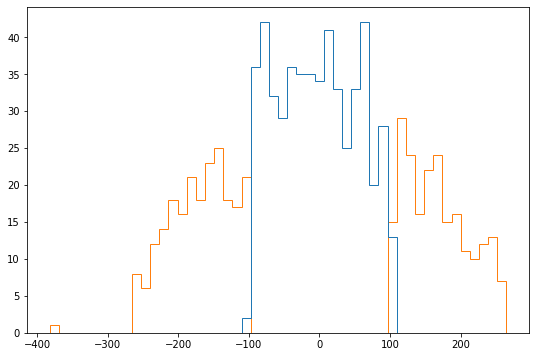

In [21]:
plt.figure(figsize=(9 ,6))
_ = plt.hist([
    [y for _, y in errors_regions['yi']['center']],
    [y for _, y in errors_regions['yi']['edges']]
], bins=50, histtype='step', label=['center', 'edges'])

In [22]:
def ImpactParameter(point,tPos,tMom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist

In [23]:
dy = ShipGeo.Yheight/u.m

def impact(origin, pos, mom):
  t = 0
  if hasattr(tMom,'P'): P = tMom.P()
  else:                 P = tMom.Mag()
  for i in range(3):   t += tMom(i)/P*(point(i)-tPos(i))
  dist = 0
  for i in range(3):   dist += (point(i)-tPos(i)-t*tMom(i)/P)**2
  dist = ROOT.TMath.Sqrt(dist)
  return dist

def get_impact(files):
    impact = dict()

    for file in files:
        f = ROOT.TFile(file)
        sTree = f.Get('cbmsim')

        if sTree.GetBranch("FitTracks_PR"): sTree.FitTracks = sTree.FitTracks_PR
        measCut = measCutPR
        if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
        if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR

        for k in range(sTree.GetEntries()):
            sTree.GetEntry(k)
            
            for i in range(sTree.FitTracks.GetEntries()):
                j = sTree.fitTrack2MC[i]
                
                
                state = sTree.FitTracks[i].getFittedState()
                
                
    return impact

In [24]:
errors_fieldmap = dict()
errors_bell = dict()

for HNL_mass in ['0.25', '0.5', '1.0']:
    results_dir = 'fieldmap-results'
    print(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
    errors_fieldmap[HNL_mass] = get_errors_regions(
        glob.glob(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
    )

for HNL_mass in ['0.25', '0.5', '1.0']:
    results_dir = 'bell-results'
    print(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
    errors_bell[HNL_mass] = get_errors_regions(
        glob.glob(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
    )

/afs/cern.ch/work/m/maborisy//fieldmap-results/m0.25*/*_rec.root


  0%|          | 0/40 [00:00<?, ?it/s]

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

  0%|          | 0/40 [00:00<?, ?it/s]

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

...

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

  0%|          | 0/40 [00:00<?, ?it/s]

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

  0%|          | 0/40 [00:00<?, ?it/s]

Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cbmsim Title: /cbmroot_0
Name: cb

In [87]:
def fitSingleGauss(h, name, color, normed=False):
    ba = h.GetBinCenter(1)
    be = h.GetBinCenter(h.GetNbinsX())
    
    bw    = h.GetBinWidth(1)
    mean  = h.GetMean()
    sigma = h.GetRMS()
    width = be - ba
    
    xs = np.array([h.GetBinCenter(i) for i in range(1, h.GetNbinsX() + 1)])
    ws = np.array([h.GetBinContent(i) for i in range(1, h.GetNbinsX() + 1)])
    cdf = np.cumsum(ws)
    
    median = xs[np.searchsorted(cdf, 0.5 * np.sum(ws))]
    low = xs[np.searchsorted(cdf, 0.15 * np.sum(ws))]
    high = xs[np.searchsorted(cdf, 0.85 * np.sum(ws))]
    
    if normed:
        myGauss = ROOT.TF1(name, f'1 /(sqrt(2 * pi * [1]**2))*exp(-0.5 * ((x - [0]) / [1])**2)', 2)
        myGauss.SetLineColor(color)
        myGauss.SetParameter(0, median)
        myGauss.SetParameter(1, (high - low) / 2)
        
        myGauss.SetParName(0, f'Mean {name}')
        myGauss.SetParName(1, f'Sigma {name}')

    else:
        norm  = h.GetEntries()*0.3

        myGauss = ROOT.TF1(name,'[2]*'+str(bw)+'/(sqrt(2 * pi * [1]**2))*exp(-0.5*((x-[0])/[1])**2)+[3]',4)
        myGauss.SetLineColor(color)
        myGauss.SetParameter(0, mean)
        myGauss.SetParameter(1, sigma)
        myGauss.SetParameter(2, norm)
        myGauss.SetParameter(3, 0.)
        
        myGauss.SetParName(0, f'Mean {name}')
        myGauss.SetParName(1, f'Sigma {name}')
        myGauss.SetParName(2, f'Signal {name}')
        myGauss.SetParName(3, f'bckgr {name}')

    
    myGauss.SetRange(ba, be)
    h.Fit(myGauss,'I','', ba, be)
    
    return myGauss

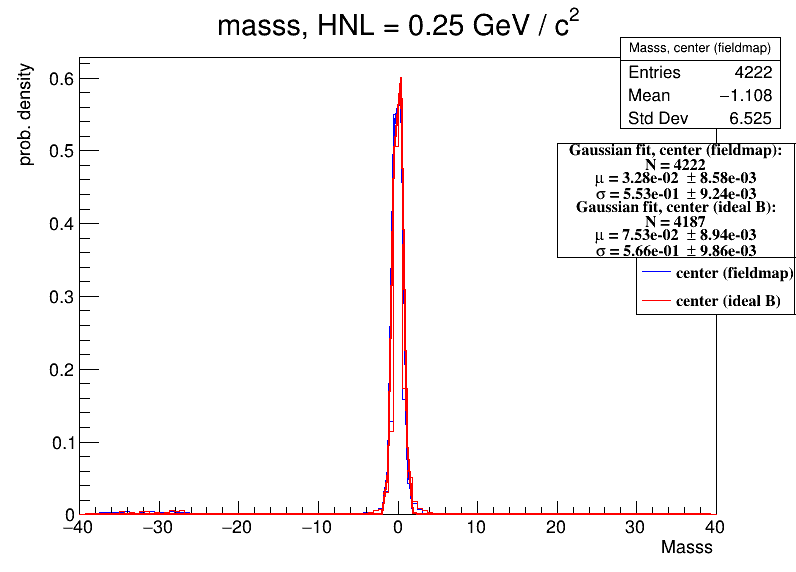

****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      462.835
NDf                       =           57
Edm                       =  1.16075e-12
NCalls                    =           47
Mean center (fieldmap)    =    0.0328455   +/-   0.00857693  
Sigma center (fieldmap)   =     0.553416   +/-   0.00924322  
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =       527.94
NDf                       =           87
Edm                       =  3.64371e-07
NCalls                    =           40
Mean center (ideal B)     =     0.075266   +/-   0.00894283  
Sigma center (ideal B)    =      0.56596   +/-   0.00985637  


Info in <TCanvas::Print>: png file test.png has been created


In [88]:
test = {
    'center (fieldmap)': errors_fieldmap['0.25']['m']['center'],
    'center (ideal B)': errors_bell['0.25']['m']['center'],
}
make_plots_regions(test, 'test.png', -40, 40, '0.25', 'masss', 'Masss')

from IPython.display import Image
display(Image(filename='test.png'))

In [89]:
def fitSingleChi(h, name, color):
    import scipy
    ba = h.GetBinCenter(1)
    be = h.GetBinCenter(h.GetNbinsX())
    
    bw    = h.GetBinWidth(1)
    mean  = h.GetMean()
    sigma = h.GetRMS()
    norm  = h.GetEntries()
    
    myChi = ROOT.TF1(name,'[0] / [1] * (x / [1])**2 * exp(-0.5*(x/[1])**2) + [2]', 0.0, be)
    myChi.SetLineColor(color)
    myChi.SetParameter(0, norm)
    myChi.SetParameter(1, sigma)
    myChi.SetParameter(2, 1.)
    myChi.SetParName(0, f'Signal {name}')
    myChi.SetParName(1, f'Sigma {name}')
    myChi.SetParName(2, f'bckgr {name}')


    print(myChi.GetParameter(0), h.GetEntries())
    print(1 / 2 ** (3 / 2 - 1) / scipy.special.gamma(3 / 2) / 6.59e-1 * h.GetEntries())


    h.Fit(myChi,'','',ba,be)
    
    return myChi

In [94]:
default_colors = [ROOT.kBlue, ROOT.kRed]

def make_plots_regions(errors, file, low, high, HNL_mass, title, quantity, std=True, chi=False, stats=False, colors=None, normalize=True):
    import numpy as np
    result = []

    fname = 'HNL'
    name = 'HNL'
    canvas = ROOT.TCanvas(f"{quantity} {fname}", "Histograms on Same Canvas", 800, 600)
    
    
    if colors is None:
        colors = dict(zip(errors, default_colors))
    
    histograms = {
        k: ROOT.TH1F(
            f'{quantity}, {k}', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};{quantity};prob',
            64, low, high
        ) for k in errors
    }
    
    fits = {}
    
    for k in errors:
        for tp, x in errors[k]:
            histograms[k].Fill(x)
        
        if normalize:
            histograms[k].Scale(1 / histograms[k].Integral('width'))

        histograms[k].SetLineColor(colors[k])
        if std:
            fits[k] = fitSingleGauss(histograms[k], k, colors[k], normed=normalize)
        elif chi:
            fits[k] = fitSingleChi(histograms[k], k, colors[k], normed=normalize)
    
    for index, k in enumerate(errors):
        if index == 0:
            histograms[k].SetMaximum(1.1 * max([
                histograms[l].GetMaximum() for l in histograms
            ]))
            histograms[k].SetMinimum(0.0)
            histograms[k].Draw('HIST')
            if normalize:
                histograms[k].GetYaxis().SetTitle("prob. density")
            else:
                histograms[k].GetYaxis().SetTitle("events")
        else:
            histograms[k].Draw('HIST SAME')
    
    if std:
        for k in fits:
            fits[k].Draw('same')
    
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, "NDC");

        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);
        
        for k in fits:
            infoBox.AddText(f"Gaussian fit, {k}:");
            infoBox.AddText(f"N = {len(errors[k])}")
            infoBox.AddText(f"#mu = {fits[k].GetParameter(0):.2e} #pm {fits[k].GetParError(0):.2e}")
            infoBox.AddText(f"#sigma = {fits[k].GetParameter(1):.2e} #pm {fits[k].GetParError(1):.2e}")

        infoBox.Draw('same')
    elif chi:
        for k in fits:
            fits[k].Draw('same')
    
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, "NDC");

        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);

        infoBox.AddText("Generalized chi fit:");
        for k in fits:
            infoBox.AddText(f"scale_{{{k}}}={fits[k].GetParameter(1):.2e} #pm {fits[k].GetParError(1):.2e}")
        
        infoBox.AddText("Statistics:");
        for k in errors:
            infoBox.AddText(f"N = {len(errors[k])}")
            xs = [x for pt, x in errors[k]]
            mean = np.median(xs)
            infoBox.AddText(f"median_{{{k}}}={mean:.2e}")

        infoBox.Draw('same')
    elif stats:
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, f"NDC");
        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);
        infoBox.SetTextAlign(12)

        for j, k in enumerate(errors):
            infoBox.AddText(f"Statistics {k}:")
            infoBox.AddText(f"    N = {len(errors[k])}")

            xs = [x for pt, x in errors[k]]
            mean = np.median(xs)
            infoBox.AddText(f"    median = {mean:.2e}")
            mean = np.mean(xs)
            mean_error = np.std(xs) / np.sqrt(len(xs) - 1)
            infoBox.AddText(f"    mean = {mean:.2e} #pm {mean_error:.2e}")

            infoBox.Draw('same')
        

    legend = ROOT.TLegend(0.8, 0.45, 1.0, 0.55)
    legend.SetFillColor(0);
    legend.SetTextSize(0.03);
    legend.SetTextFont(22);
    legend.SetBorderSize(1);
    for k in histograms:
        legend.AddEntry(histograms[k], k, "l")
    legend.Draw()

    canvas.Draw()
    canvas.SaveAs(file.format(fname=fname))
    result.append(file.format(fname=fname))
    return result

In [108]:
import numpy as np

def get_softrange(xs, quantile=0.025, margin=0.05):
    low, high = np.quantile(xs, q=(quantile, 1 - quantile))
    delta = high - low
    left, right = max(low - margin * delta, np.min(xs)), min(high + margin * delta, np.max(xs))
    return left, right
    

def minmax(errors, q, quantile=0.025, margin=0.05):
    xs = np.array([
        get_softrange([e for _, e in errors[m][q][k]], quantile=quantile, margin=margin)
        for m in errors for k in errors[m][q] 
    ])
    
    return np.min(xs[:, 0]), np.max(xs[:, 1])

bounds = dict()

quantiles = {
    'y': 0.025,
    'yi': 0.025
}

default_quantile = 0.1

margins = {
    'y': 0.2,
    'yi': 0.2
}

default_margin = 0.0125

for q in errors_fieldmap['0.25']:
    min1, max1 = minmax(
        errors_fieldmap, q,
        quantile=quantiles.get(q, default_quantile),
        margin=margins.get(q, default_margin)
    )
    min2, max2 = minmax(
        errors_bell, q,
        quantile=quantiles.get(q, default_quantile),
        margin=margins.get(q, default_margin)
    )
    bounds[q] = (min(min1, min2), max(max1, max2))

In [109]:
outdir = 'plots-regions'
os.makedirs(outdir, exist_ok=True)

titles = {
    'm': 'Mass resolution',
    'p': 'Momentum',
    'px': 'p_{x}',
    'py': 'p_{y}',
    'pz': 'p_{z}',
    'pt': 'p_{T}',
    'ip': 'Impact parameter to origin',
    'dp_over_p': '#Delta p / p',
    'y': 'intersection with Tracker 2 (daughters), y-axis',
    'yi': 'extrapolated intersection with Tracker 2 (HNL), y-axis'
}

quantities = {
    'm': 'mass error [MeV]',
    'p': 'momentum error',
    'px': 'momentum error',
    'py': 'momentum error',
    'pz': 'momentum error',
    'pt': 'momentum error',
    'ip': 'Impact parameter [cm]',
    'dp_over_p': '#Delta p / p',
    'y': 'intersection with Tracker 2, y-axis [cm]',
    'yi': 'intersection with Tracker 2, y-axis [cm]'
}

one_sided = {
    'm': False,
    'p': False,
    'px': False,
    'py': False,
    'pz': False,
    'pt': True,
    'ip': True,
    'dp_over_p': False,
    'y': True,
    'yi': True
}

stats = {
    'y': False,
    'yi': False
}

normalize = {
    'y': False,
    'yi': False
}

all_files = []

for HNL_mass, fname in zip(['0.25', '0.5', '1.0'], ['0250', '0500', '1000']):
    for q in errors_fieldmap[HNL_mass]:
        print(HNL_mass, q)
        
        left, right = bounds[q]
        errors = {
            'center (new field)': errors_fieldmap[HNL_mass][q]['center'],
            'edges (new field)': errors_fieldmap[HNL_mass][q]['edges'],
        }
        
        files = make_plots_regions(
            errors, f'{outdir}/m{fname}-{q}.png',
            left, right, HNL_mass,
            title=titles[q], quantity=quantities[q], std=not one_sided[q], chi=False,
            stats=stats.get(q, True), normalize=normalize.get(q, True)
        )
        all_files.extend(files)

for HNL_mass, fname in zip(['0.25', '0.5', '1.0'], ['0250', '0500', '1000']):
    for q in errors_fieldmap[HNL_mass]:
        print(HNL_mass, q)
        
        left, right = bounds[q]
        errors = {
            'center (new field)': errors_fieldmap[HNL_mass][q]['center'],
            'center (old field)': errors_bell[HNL_mass][q]['center'],
        }
        files = make_plots_regions(
            errors, f'{outdir}/m{fname}-{q}-center.png',
            left, right, HNL_mass,
            title=titles[q], quantity=quantities[q], std=not one_sided[q], chi=False,
            stats=stats.get(q, True), normalize=normalize.get(q, True)
        )
        all_files.extend(files)

for HNL_mass, fname in zip(['0.25', '0.5', '1.0'], ['0250', '0500', '1000']):
    for q in errors_fieldmap[HNL_mass]:
        print(HNL_mass, q)
        
        left, right = bounds[q]
        errors = {
            'edges (new field)': errors_fieldmap[HNL_mass][q]['edges'],
            'edges (old field)': errors_bell[HNL_mass][q]['edges'],
        }
        files = make_plots_regions(
            errors, f'{outdir}/m{fname}-{q}-edges.png',
            left, right, HNL_mass,
            title=titles[q], quantity=quantities[q], std=not one_sided[q], chi=False,
            stats=stats.get(q, True), normalize=normalize.get(q, True)
        )
        all_files.extend(files)

0.25 m
0.25 pz
0.25 pt
0.25 px
0.25 py
0.25 p
0.25 dp_over_p
0.25 ip
0.25 y
0.25 yi
0.5 m
0.5 pz
0.5 pt
0.5 px
0.5 py
0.5 p
0.5 dp_over_p
0.5 ip
0.5 y
0.5 yi
1.0 m
1.0 pz
1.0 pt
1.0 px
1.0 py
1.0 p
1.0 dp_over_p
1.0 ip
1.0 y
1.0 yi
0.25 m
0.25 pz
0.25 pt
0.25 px
0.25 py
0.25 p
0.25 dp_over_p
0.25 ip
0.25 y
0.25 yi
0.5 m
0.5 pz
0.5 pt
0.5 px
0.5 py
0.5 p
0.5 dp_over_p
0.5 ip
0.5 y
0.5 yi
1.0 m
1.0 pz
1.0 pt
1.0 px
1.0 py
1.0 p
1.0 dp_over_p
1.0 ip
1.0 y
1.0 yi
0.25 m
0.25 pz
0.25 pt
0.25 px
0.25 py
0.25 p
0.25 dp_over_p
0.25 ip
0.25 y
0.25 yi
0.5 m
0.5 pz
0.5 pt
0.5 px
0.5 py
0.5 p
0.5 dp_over_p
0.5 ip
0.5 y
0.5 yi
1.0 m
1.0 pz
1.0 pt
1.0 px
1.0 py
1.0 p
1.0 dp_over_p
1.0 ip
1.0 y
1.0 yi
****************************************
Minimizer is Minuit2 / Migrad
Chi2                      =      359.095
NDf                       =           34
Edm                       =  2.99579e-06
NCalls                    =           42
Mean center (new field)   = -0.000549231   +/-   0.00945507  
Sigma c

Info in <TCanvas::Print>: png file plots-regions/m0250-m.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-pz.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-pt.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-px.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-py.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-p.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-dp_over_p.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-ip.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-y.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0250-yi.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0500-m.png has been created
Info in <TCanvas::Print>: png file plots-regions/m0500-pz.png has been created
Info in <TCanvas::Print>: png file plots-regions/

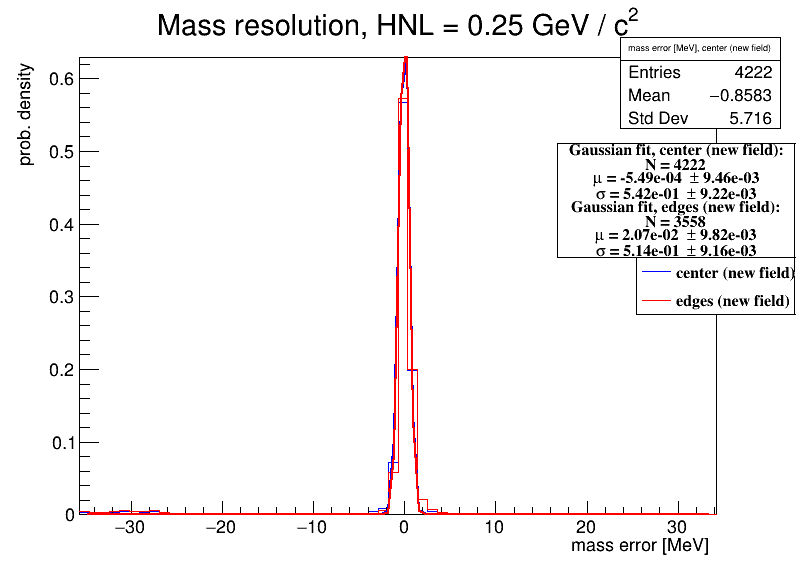

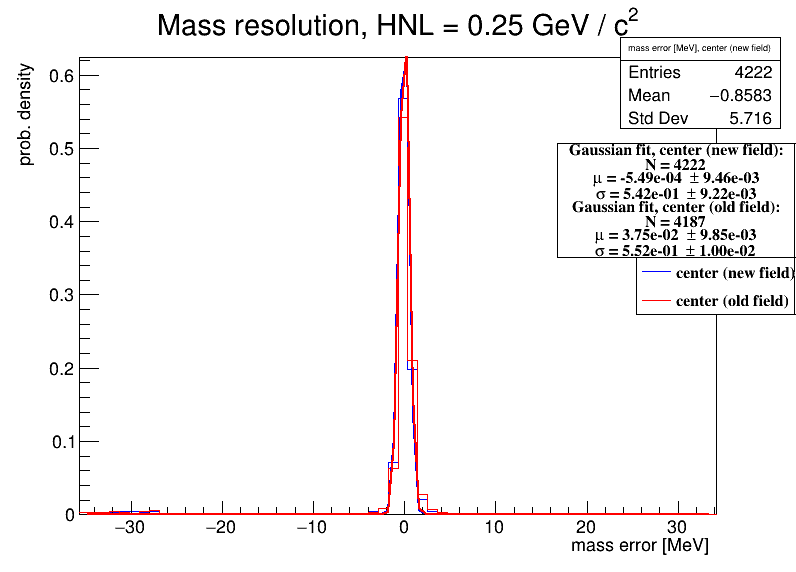

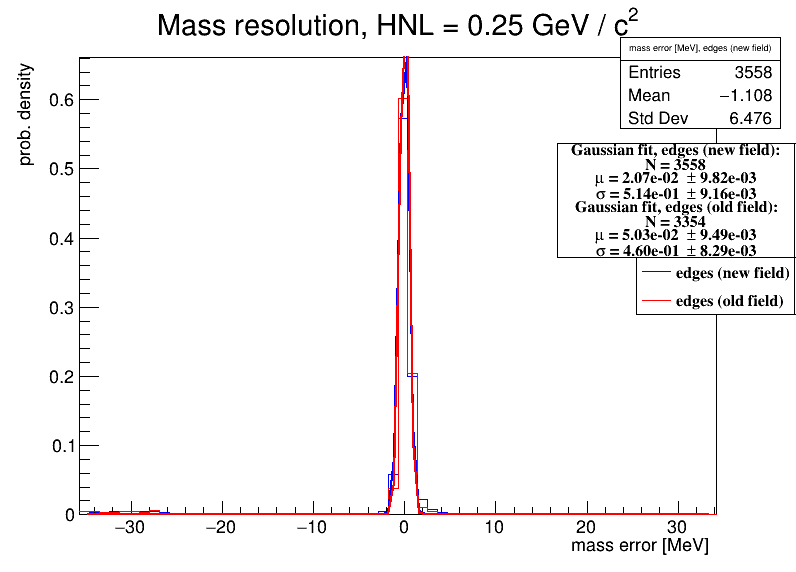

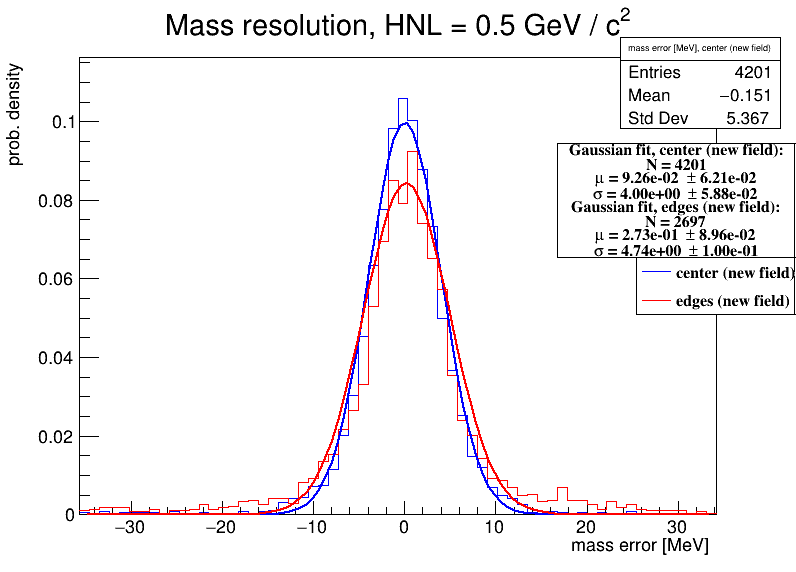

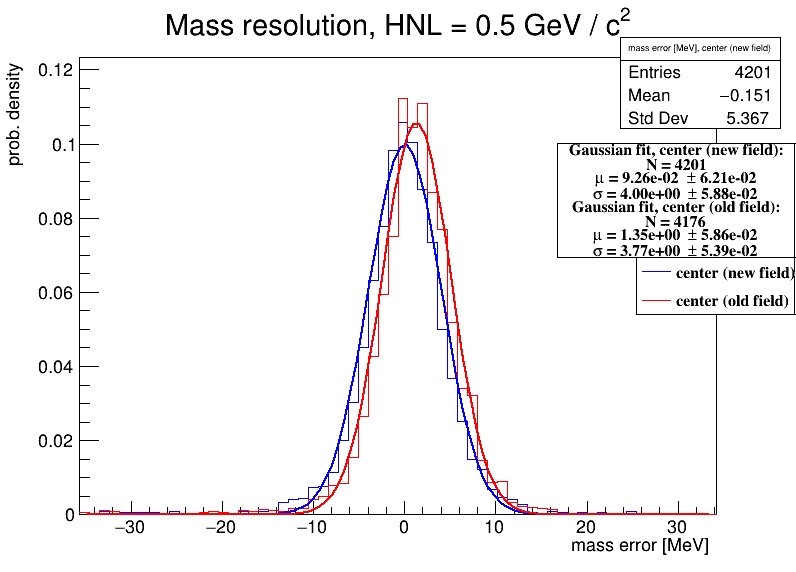

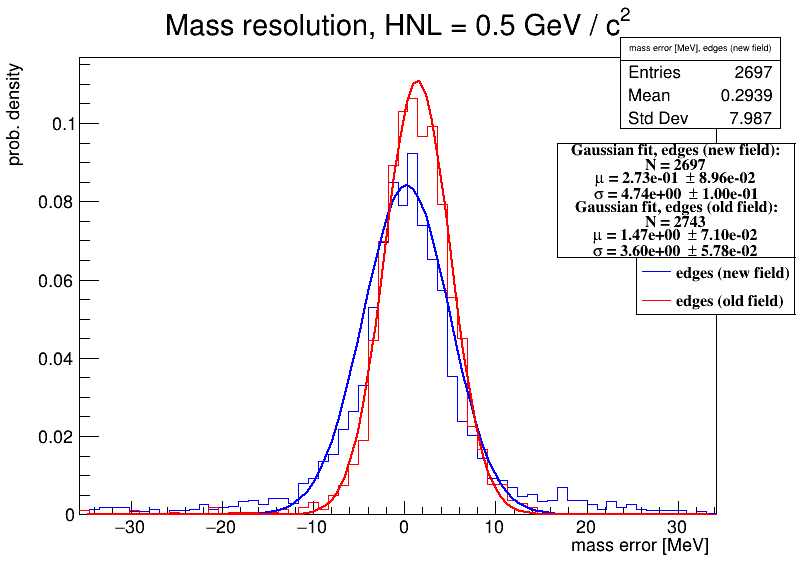

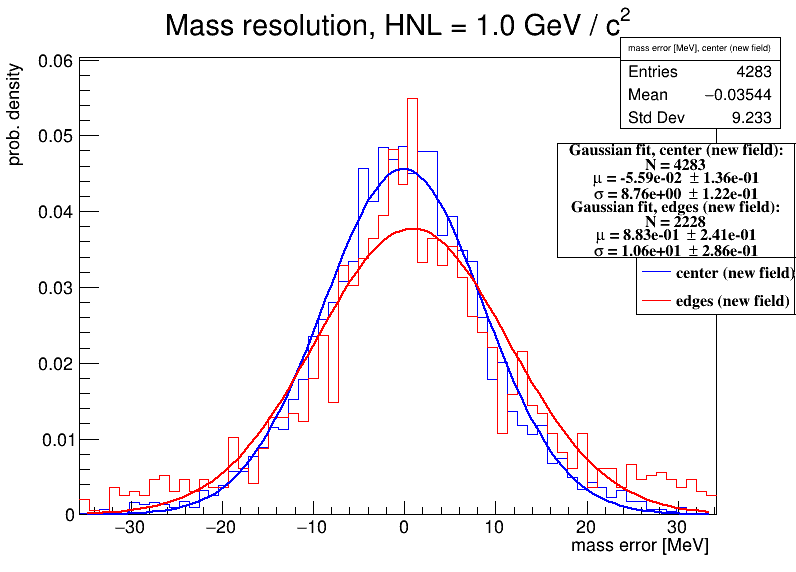

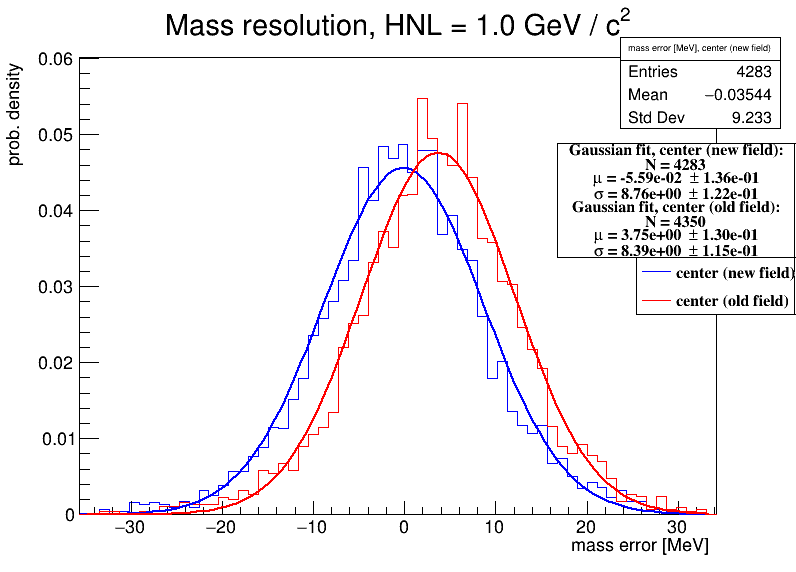

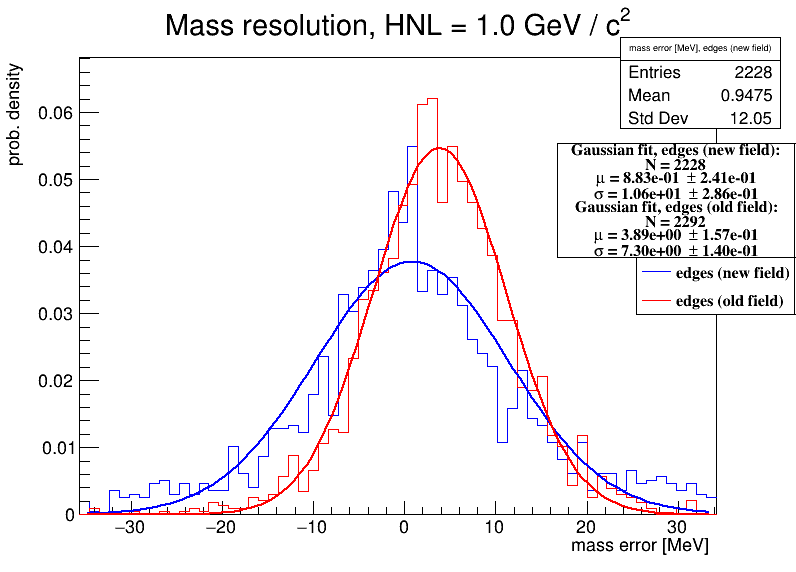

In [112]:
from IPython.display import Image

# for file in all_files:
#     display(Image(filename=file))

for fname in ['0250', '0500', '1000']:
    display(Image(filename=f'{outdir}/m{fname}-m.png'))
    display(Image(filename=f'{outdir}/m{fname}-m-center.png'))
    display(Image(filename=f'{outdir}/m{fname}-m-edges.png'))

In [ ]:
def make_momentum_plots(errors_old, errors_new, axis, file, low, high, HNL_mass):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    
    for fname, pts, name in groups:
        canvas = ROOT.TCanvas(f"momentum resolution {fname}", "Histograms on Same Canvas", 800, 600)
        
        key_old = f'{axis}-momentum resolution {fname} old'
        h_old = ROOT.TH1F(
            key_old, f'{axis}-momentum resolution {name}, HNL = {HNL_mass} GeV / c^{{2}};momentum error;prob',
            50, low, high
        )
        
        key_new = f'{axis}-momentum resolution {fname} new'
        h_new = ROOT.TH1F(
            key_new, f'{axis}-momentum resolution {name}, HNL = {HNL_mass} GeV / c^{{2}};momentum error;prob',
            50, low, high
        )
        
        h = {key_old: h_old, key_new: h_new}

        for pt in pts:
            if pt in errors_old:
                for x in errors_old[pt]:
                    h_old.Fill(x)
        for pt in pts:
            if pt in errors_new:
                for x in errors_new[pt]:
                    h_new.Fill(x)
        
        h_old.SetLineColor(ROOT.kBlue)
        h_new.SetLineColor(ROOT.kRed)
        h_old.DrawNormalized()
        h_new.DrawNormalized('SAME')
        # fitSingleGauss(h, key)
        
        
        
        # Create a legend
        legend = ROOT.TLegend(0.75, 0.65, 0.9, 0.75)
        legend.AddEntry(h1, "Old field", "l")
        legend.AddEntry(h2, "New field", "l")
        legend.Draw()
        
        canvas.Draw()
        
        canvas.SaveAs(file.format(fname=fname))
        result.append(file.format(fname=fname))
    return result

In [ ]:
def make_plots(errors_old, errors_new, file, low, high, HNL_mass, title, quantity, std=True, chi=False):
    import numpy as np
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
#     for fname, pts, name in groups:
    fname = 'HNL'
    name = 'HNL'
    canvas = ROOT.TCanvas(f"{quantity} {fname}", "Histograms on Same Canvas", 800, 600)

    h_old = ROOT.TH1F(
        f'{quantity}, old field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};{quantity};prob',
        35, low, high
    )

    h_new = ROOT.TH1F(
        f'{quantity}, new field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};{quantity};prob',
        35, low, high
    )

    xs_old = list()
#     for pt in pts:
#         if pt in errors_old:
    for tp, x in errors_old:
        h_old.Fill(x)
        xs_old.append(x)
    h_old.SetLineColor(ROOT.kBlue)
    if std:
        fit_old = fitSingleGauss(h_old, '1', ROOT.kBlue)
    elif chi:
        fit_old = fitSingleChi(h_old, '1', ROOT.kBlue)

    xs_new = list()
#     for pt in pts:
#         if pt in errors_new:
    for tp, x in errors_new:
        h_new.Fill(x)
        xs_new.append(x)
    h_new.SetLineColor(ROOT.kRed)
    if std:
        fit_new = fitSingleGauss(h_new, '2', ROOT.kRed)
    elif chi:
        fit_new = fitSingleChi(h_new, '2', ROOT.kRed)

    h_old.Draw()
    h_new.Draw('SAME')
    
    if std:
        fit_old.Draw('same')
        fit_new.Draw('same')
    
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, "NDC");

        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);

        infoBox.AddText("Gaussian fit:");
        infoBox.AddText(f"#mu_{{old}}={fit_old.GetParameter(1):.2e} #pm {fit_old.GetParError(1):.2e}")
        infoBox.AddText(f"#sigma_{{old}}={fit_old.GetParameter(2):.2e} #pm {fit_old.GetParError(2):.2e}")
        infoBox.AddText(f"#mu_{{new}}={fit_new.GetParameter(1):.2e} #pm {fit_new.GetParError(1):.2e}")
        infoBox.AddText(f"#sigma_{{new}}={fit_new.GetParameter(2):.2e} #pm {fit_new.GetParError(2):.2e}")

        infoBox.Draw('same')
    elif chi:
        fit_old.Draw('same')
        fit_new.Draw('same')
    
        infoBox = ROOT.TPaveText(0.7, 0.55, 1.0, 0.75, "NDC");

        infoBox.SetFillColor(0);
        infoBox.SetTextSize(0.03);
        infoBox.SetTextFont(22);
        infoBox.SetBorderSize(1);

        infoBox.AddText("Generalized chi fit:");
        infoBox.AddText(f"scale_{{old}}={fit_old.GetParameter(1):.2e} #pm {fit_old.GetParError(1):.2e}")
        infoBox.AddText(f"scale_{{new}}={fit_new.GetParameter(1):.2e} #pm {fit_new.GetParError(1):.2e}")
        
        mean_old = np.median(xs_old)
        error_mean_old = np.std(xs_old) / np.sqrt(len(xs_old) - 1)
        mean_new = np.median(xs_new)
        error_mean_new = np.std(xs_new) / np.sqrt(len(xs_new) - 1)
        
        infoBox.AddText("Statistics:");
        infoBox.AddText(f"median_{{old}}={mean_old:.2e}")
        infoBox.AddText(f"median_{{new}}={mean_new:.2e}")

        infoBox.Draw('same')
        

    # Create a legend
    mean_old, mean_new = np.mean(xs_old), np.mean(xs_new)
    std_old, std_new = np.std(xs_old, ddof=1), np.std(xs_new, ddof=1)
    error_mean_old = std_old / np.sqrt(len(xs_old) - 1)
    error_mean_new = std_new / np.sqrt(len(xs_new) - 1)
    error_std_old = std_old / np.sqrt(2) / np.sqrt(len(xs_old) - 1)
    error_std_new = std_new / np.sqrt(2) / np.sqrt(len(xs_new) - 1)
    legend = ROOT.TLegend(0.8, 0.45, 1.0, 0.55)
    legend.SetFillColor(0);
    legend.SetTextSize(0.03);
    legend.SetTextFont(22);
    legend.SetBorderSize(1);
    legend.AddEntry(h_old, f"Old field", "l")
    legend.AddEntry(h_new, f"New field", "l")
    legend.Draw()

    canvas.Draw()
    canvas.SaveAs(file.format(fname=fname))
    result.append(file.format(fname=fname))
    return result

In [ ]:
fitSingleChi

In [ ]:
import scipy.special

In [ ]:
1 / 2 ** (3 / 2 - 1) / scipy.special.gamma(3 / 2) / 6.59e-1 * 212

In [ ]:
from IPython.display import Image

files = make_plots(
    errors_old['ip'], errors_new['ip'], 'test.png', 0.0, 10.00, HNL_mass, std=False, chi=True,
    title='p_{T}', quantity='#Delta p_{T}'
)
for file in files:
    display(Image(filename=file))

In [ ]:
def make_2D_plots(errors, file, low_p, high_p, low_y, high_y, HNL_mass, title, quantity, std=True):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    # for fname, pts, name in groups:
    canvas = ROOT.TCanvas(f"{quantity}", "Histograms on Same Canvas", 800, 600)

    h = ROOT.TH2D(
        f'{quantity} old field', f'{title}, HNL = {HNL_mass} GeV / c^{{2}};true momentum;{quantity}',
        20, low_p, high_p, 20, low_y, high_y
    )

    for tp, x in errors:
        h.Fill(tp, x)

    h.Draw('COLORZ')

    canvas.Draw()
    canvas.SaveAs(file.format(fname=fname))
    result.append(file.format(fname=fname))
    return result

In [ ]:
errors = dict()

for HNL_mass in ['0.25']:#, '0.5', '1.0']:
    errors[HNL_mass] = dict()

    for B, results_dir in zip(['new', 'old'], ['field_local_regression', 'field_local_old']):
        print(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')
        errors[HNL_mass][B] = \
            get_errors(
                glob.glob(f'{path}/{results_dir}/m{HNL_mass}*/*_rec.root')[:30]
            )

In [ ]:
import numpy as np
def minmax(errors, q):
    xs = np.array([
        e for m in errors for B in errors[m] for _, e in errors[m][B][q]
    ])
    
    low, high = np.quantile(xs, q=(0.05, 0.95))
    
    delta = high - low
    
    left, right = max(low - 0.2 * delta, np.min(xs)), min(high + 0.2 * delta, np.max(xs))
    return left, right

In [ ]:
bounds = dict()

for q in errors['0.25']['old']:
    bounds[q] = minmax(errors, q)

In [ ]:
outdir = 'plots'
os.makedirs(outdir, exist_ok=True)

titles = {
    'm': 'Mass resolution',
    'p': 'Momentum',
    'px': 'p_{x}',
    'py': 'p_{y}',
    'pz': 'p_{z}',
    'pt': 'p_{T}',
    'ip': 'Impact parameter to origin',
    'dp_over_p': '#Delta p / p'
}

quantities = {
    'm': 'mass error [MeV]',
    'p': 'momentum error',
    'px': 'momentum error',
    'py': 'momentum error',
    'pz': 'momentum error',
    'pt': 'momentum error',
    'ip': 'Impact parameter [cm]',
    'dp_over_p': '#Delta p / p'
}

one_sided = {
    'm': False,
    'p': False,
    'px': False,
    'py': False,
    'pz': False,
    'pt': True,
    'ip': True,
    'dp_over_p': False
}

chi = {
    'm': False,
    'p': False,
    'px': False,
    'py': False,
    'pz': False,
    'pt': False,
    'ip': True,
    'dp_over_p': False
}

all_files = []

for HNL_mass, fname in zip(['0.25'], ['0250', '0500', '1000']):
    for q in errors[HNL_mass]['old']:
        print(HNL_mass, q)
        
        left, right = bounds[q]
        files = make_plots(
            errors[HNL_mass]['old'][q], errors[HNL_mass]['new'][q], f'{outdir}/m{fname}-{q}.png',
            left, right, HNL_mass,
            title=titles[q], quantity=quantities[q], std=not one_sided[q], chi=chi[q]
        )
        all_files.extend(files)

max_p = 10.0
        
for HNL_mass, fname in zip(['0.25'], ['0250', '0500', '1000']):
    for B in ['old', 'new']:
        for q in errors[HNL_mass]['old']:
            left, right = bounds[q]
            files = make_2D_plots(
                errors[HNL_mass][B][q],
                f'{outdir}/m{fname}-{B}-{q}.png',
                0.0, max_p, left, right, HNL_mass,
                title=titles[q], quantity=quantities[q]
            )
            all_files.extend(files)

In [ ]:
from IPython.display import Image

display(Image(filename="plots/m0250-ip.png"))

display(Image(filename="plots/m0250-m.png"))

display(Image(filename="plots/m0250-old-pt.png"))

display(Image(filename="plots/m0250-old-pz.png"))

display(Image(filename="plots/m0250-old-ip.png"))

display(Image(filename="plots/m0250-old-dp_over_p.png"))

In [ ]:
def make_impact_plots(err_old, err_new, file, low, high, HNL_mass):
    result = []

    groups = [
        ('mu', ['mu-'], '#mu^{-}'),
        ('anti-mu', ['mu+'], '#mu^{+}'),
        ('muon', ['mu-', 'mu+'], '#mu'),
        
        ('pi', ['pi-'], '#pi^{-}'),
        ('anti-pi', ['pi+'], '#pi^{+}'),
        ('pi0', ['pi0'], '#pi^{0}'),
        ('pion', ['pi-', 'pi+', 'pi0'], '#pi'),
    ]
    for fname, pts, name in groups:
        h = dict()
        key = f'impact parameter {fname}'
        ut.bookHist(
            h, key, f'impact parameter to origin {name}, HNL = {HNL_mass} GeV / c^{{2}}',
            50, low, high
        )

        for pt in pts:
            if pt in errors:
                for x in errors[pt]:
                    h[key].Fill(x)

        # fitSingleGauss(h, f'impact parameter {fname}')

        canvas = ROOT.TCanvas()
        h[key].SetXTitle('impact parameter, cm')
        h[key].Draw()
        canvas.SaveAs(file.format(fname=fname))
        result.append(file.format(fname=fname))
    return result

In [ ]:
px_files = make_momentum_plots(px_errors, 'x', 'field-m025-px-{fname}.png')

from IPython.display import Image

for file in px_files:
    display(Image(filename=file))

In [ ]:
from IPython.display import Image

display(Image(filename="m025-mass-pi0.png"))

In [ ]:
h['mass resolution'].Save()

In [ ]:
errors = []

for k in range(sTree.GetEntries()):
    sTree.GetEntry(k)

    for i in range(sTree.FitTracks.GetEntries()):
        j = sTree.fitTrack2MC[i]

        momentum = ROOT.TVector3() 
        sTree.MCTrack[j].GetMomentum(momentum)
        tx, ty, tz = momentum
        true_mass = sTree.MCTrack[j].GetMass()

        pid = sTree.MCTrack[j].GetPdgCode()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'

        state = sTree.FitTracks[i].getFittedState()
        x, y, z = state.getMom()
        mass = state.getMass()
        pid = state.getPDG()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'

        mass_error = mass - true_mass
        # print(f'{name}: {mass_error} ({mass} / {true_mass})')
        errors.append(mass_error / u.GeV)

In [ ]:
for ahit in sTree.strawtubesPoint:
    Ptruthx,Ptruthy,Ptruthz = ahit.GetPx(),ahit.GetPy(),ahit.GetPz()
    print(Ptruthx,Ptruthy,Ptruthz)
    Ptruth  = ROOT.TMath.Sqrt(Ptruthx**2+Ptruthy**2+Ptruthz**2)

In [ ]:
u.m

In [ ]:
ahit

In [ ]:
for i in range(sTree.MCTrack.GetEntries()):
    mother_id = sTree.MCTrack[i].GetMotherId()
    pid = sTree.MCTrack[i].GetPdgCode()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        name = '(unknown)'

    x, y, z = sTree.MCTrack[i].GetStartX(), sTree.MCTrack[i].GetStartY(), sTree.MCTrack[i].GetStartZ()

    inside = isInFiducial(x, y, z)

    print(f'Particle {i}, type: {name} ({pid}), mother: {mother_id}')

In [ ]:
# sTree.GetBranch('FitTracks_PR')

In [ ]:
momentum = ROOT.TVector3()
sTree.MCTrack[i].GetMomentum(momentum)

In [ ]:
pdgDB.GetParticle(pid)

In [ ]:
from array import array
def dist2InnerWall(X,Y,Z):
  dist = 0
 # return distance to inner wall perpendicular to z-axis, if outside decayVolume return 0.
  node = sGeo.FindNode(X,Y,Z)
  if ShipGeo.tankDesign < 5:
     if not 'cave' in node.GetName(): return dist  # TP
  else:
     if not 'DecayVacuum' in node.GetName(): return dist
  start = array('d',[X,Y,Z])
  nsteps = 8
  dalpha = 2*ROOT.TMath.Pi()/nsteps
  rsq = X**2+Y**2
  minDistance = 100 *u.m
  for n in range(nsteps):
    alpha = n * dalpha
    sdir  = array('d',[ROOT.TMath.Sin(alpha),ROOT.TMath.Cos(alpha),0.])
    node = sGeo.InitTrack(start, sdir)
    nxt = sGeo.FindNextBoundary()
    if ShipGeo.tankDesign < 5 and nxt.GetName().find('I')<0: return 0
    distance = sGeo.GetStep()
    if distance < minDistance  : minDistance = distance
  return minDistance

def isInFiducial(X,Y,Z):
   if not fiducialCut: return True
   if Z > ShipGeo.TrackStation1.z : return False
   if Z < ShipGeo.vetoStation.z+100.*u.cm : return False
   # typical x,y Vx resolution for exclusive HNL decays 0.3cm,0.15cm (gaussian width)
   if dist2InnerWall(X,Y,Z)<5*u.cm: return False
   return True

In [ ]:
track2MC = sTree.fitTrack2MC

In [ ]:
track2MC[0]

In [ ]:
for i in range(sTree.FitTracks.GetEntries()):
    j = track2MC[i]

    momentum = ROOT.TVector3() 
    sTree.MCTrack[j].GetMomentum(momentum)
    x, y, z = momentum
    m = sTree.MCTrack[j].GetMass()
    
    pid = sTree.MCTrack[j].GetPdgCode()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        print(pid)
        name = '(unknown)'
    
    print(name, m)
    print(x, y, z)
    
    state = sTree.FitTracks[i].getFittedState()
    x, y, z = state.getMom()
    m = state.getMass()
    pid = state.getPDG()
    try:
        name = pdgDB.GetParticle(pid).GetName()
    except:
        print(pid)
        name = '(unknown)'
    
    print(name, m)
    print(x, y, z)
    
    print()

In [ ]:
dir(state)

In [ ]:
import subprocess as sp

with open('event.dot', 'w') as g:
    g.write('digraph G {\n rankdir=LR;\n')

    for i in range(sTree.MCTrack.GetEntries()):
        mother_id = sTree.MCTrack[i].GetMotherId()
        pid = sTree.MCTrack[i].GetPdgCode()
        try:
            name = pdgDB.GetParticle(pid).GetName()
        except:
            print(pid)
            name = '(unknown)'
        
        x, y, z = sTree.MCTrack[i].GetStartX(), sTree.MCTrack[i].GetStartY(), sTree.MCTrack[i].GetStartZ()
        
        inside = isInFiducial(x, y, z)

        # print(f'Particle {i}, type: {name} ({pid}), mother: {mother_id}')
        if inside:
            g.write(f'p_{i}[label="{name}", style=filled, fillcolor=red]')
        else:
            g.write(f'p_{i}[label="{name}"];\n')
        g.write(f'p_{mother_id} -> p_{i};\n')
    
    g.write('}')

p = sp.run(['dot', 'event.dot', '-Tpng'], capture_output=True, text=False)
with open('event.png', 'wb') as g:
    g.write(p.stdout)
from IPython.display import Image

display(Image(filename="event.png"))

In [ ]:
if sTree.GetBranch("FitTracks_PR"):
    sTree.FitTracks = sTree.FitTracks_PR
measCut = measCutPR
if sTree.GetBranch("fitTrack2MC_PR"):  sTree.fitTrack2MC = sTree.fitTrack2MC_PR
if sTree.GetBranch("Particles_PR"):    sTree.Particles   = sTree.Particles_PR
# if not checkHNLorigin(sTree): pass
if not sTree.MCTrack.GetEntries()>1: wg = 1.
else:   wg = sTree.MCTrack[1].GetWeight()
if not wg>0.: wg=1.

In [ ]:
def print_tree_structure(tree, prefix=""):
    """ Recursively prints the TTree structure in a hierarchical way """
    for branch in tree.GetListOfBranches():
        print(f"{prefix}├── {branch.GetName()} ({branch.GetClassName()})")
        print_tree_structure(branch, prefix + "│   ")

In [ ]:
sTree.strawtubesPoint.GetEvent(0)

In [ ]:
for p in sTree.strawtubesPoint:
    try:
        p.GetEntry(0)
        print(p.fDetectorID)
    except:
        pass

In [ ]:
import subprocess as sp

def save_histograms_as_images(input_file, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    f_in = ROOT.TFile.Open(input_file, "READ")
    
    if not f_in or f_in.IsZombie():
        print("Error: Unable to open file!")
        return

    count = 0
    for key in f_in.GetListOfKeys():
        obj = key.ReadObj()
        if isinstance(obj, ROOT.TH1):  # Check if object is a histogram
            count += 1
            c1 = ROOT.TCanvas("c1", "Canvas")
            obj.Draw()
            hist_name = obj.GetName()
            hist_title = obj.GetTitle()

            # Replace spaces or special characters in the name to create valid filenames
            hist_name = hist_name.replace(" ", "_").replace("/", "_").replace("\\", "_")
            
            output_file = os.path.join(output_dir, f"{hist_name}.png")
            c1.SaveAs(output_file)  # Save as PNG
            del c1

    f_in.Close()
    print(f"{count} histograms saved as images in {output_dir}")
    
    direc = os.path.dirname(input_file)
    
    for item in glob.glob(f'{direc}/*.gif'):
        item = os.path.basename(item)
        print(os.path.join(direc, item), os.path.join(output_dir, item))
        sp.run(['cp', os.path.join(direc, item), os.path.join(output_dir, item)])

In [ ]:
!mkdir -p hist-new-0250/
!mkdir -p hist-new-0500/
!mkdir -p hist-new-1000/

In [ ]:
save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m0.25/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-0250/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m0.5/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-0500/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local/m1.0/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-new-1000/"
)

In [ ]:
save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m0.25/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-0250/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m0.5/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-0500/"
)

save_histograms_as_images(
    "/afs/cern.ch/work/m/maborisy/field_local_old/m1.0/ship.conical.Pythia8-TGeant4-1_ana.root",
    "hist-old-1000/"
)

In [ ]:
sTree.strawtubesPoint.At(0)

In [ ]:
branch = sTree.GetBranch('strawtubesPoint.fDetectorID')
# for branch in branch.GetListOfBranches():
#     if branch.GetName() == 'strawtubesPoint.fDetectorID':
#         break

In [ ]:
branch.Print()

In [ ]:
print_tree_structure(sTree)

In [ ]:
sTree.GetEvent(0)
v = sTree.FitTracks

In [ ]:
v.ls()

In [ ]:
particles = sTree.GetBranch('Particles')

In [ ]:
particles.GetListOfBranches().Print()

In [ ]:
particles.GetEntry(0)